In [1]:
!pip install tensorflow pandas matplotlib scikit-learn

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Check TensorFlow version and GPU availability (optional but good for debugging)
print(f"TensorFlow Version: {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2026-02-17 19:50:23.742019: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-17 19:50:23.742173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-17 19:50:24.952230: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-17 19:50:27.442016: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-17 19:50:34.712425: W tensorflow/compiler/tf2

In [7]:
%pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]/2 [kagglehub]
Note: you may need to restart the kernel to use updated packages.


In [8]:
import kagglehub
import numpy as np
import os
import gzip
from tensorflow import keras

print("Downloading KMNIST from Kaggle...")

# Download the KMNIST dataset (anokas/kuzushiji is the correct KMNIST repo on Kaggle)
# This downloads the files to a local cache directory
path = kagglehub.dataset_download("anokas/kuzushiji")

print("Path to dataset files:", path)

# Function to load the .gz files from the downloaded path
def load_kmnist_from_path(data_path):
    # Define file names expected in the Kaggle dataset
    files = {
        'train_img': 'train-images-idx3-ubyte.gz',
        'train_lbl': 'train-labels-idx1-ubyte.gz',
        'test_img': 't10k-images-idx3-ubyte.gz',
        'test_lbl': 't10k-labels-idx1-ubyte.gz'
    }

    def load_images(filename):
        filepath = os.path.join(data_path, filename)
        with gzip.open(filepath, 'rb') as f:
            # Skip first 16 bytes (header) and read data
            data = np.frombuffer(f.read(), np.uint8, offset=16)
        # Reshape to (Num_Images, 28, 28)
        return data.reshape(-1, 28, 28)

    def load_labels(filename):
        filepath = os.path.join(data_path, filename)
        with gzip.open(filepath, 'rb') as f:
            # Skip first 8 bytes (header) and read data
            data = np.frombuffer(f.read(), np.uint8, offset=8)
        return data

    # Load the data
    x_train = load_images(files['train_img'])
    y_train = load_labels(files['train_lbl'])
    x_test = load_images(files['test_img'])
    y_test = load_labels(files['test_lbl'])

    return (x_train, y_train), (x_test, y_test)

# Load data into variables
(train_images, train_labels), (test_images, test_labels) = load_kmnist_from_path(path)

# --- Preprocessing ---

# 1. Normalize pixel values (0-255 -> 0.0-1.0)
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# 2. One-hot encode labels (0 -> [1,0,0,...])
train_labels = keras.utils.to_categorical(train_labels, 10)
test_labels = keras.utils.to_categorical(test_labels, 10)

print("\nSUCCESS! Data loaded and processed.")
print(f"Training set shape: {train_images.shape}")
print(f"Test set shape: {test_images.shape}")

Path to dataset files: /home/azureuser/.cache/kagglehub/datasets/anokas/kuzushiji/versions/3

SUCCESS! Data loaded and processed.
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)


 96%|█████████▋| 550M/571M [00:09<00:00, 34.4MB/s] 


In [9]:
# 2. MODEL DEFINITION
def create_model():
    """
    Creates a feedforward fully connected neural network 
    based on the project requirements.
    """
    model = keras.Sequential([
        # Input Layer: Flatten 28x28 images to a 784 vector
        layers.Flatten(input_shape=(28, 28)),
        
        # Hidden Layer 1: 128 neurons with ReLU activation
        layers.Dense(128, activation='relu'),
        
        # Hidden Layer 2: 64 neurons with ReLU activation
        layers.Dense(64, activation='relu'),
        
        # Output Layer: 10 neurons (classes) with Softmax activation
        layers.Dense(10, activation='softmax')
    ])
    return model

In [10]:
# 3. EXPERIMENT CONFIGURATION
# List of optimizers to compare
optimizers_to_test = ['Adam', 'RMSprop', 'AdamW']

# Learning rates for hyperparameter tuning
learning_rates = [0.001, 0.01] 

# Cross-validation settings
n_folds = 5 
epochs = 10  # Number of epochs per fold
batch_size = 64

print(f"Configuration set: {len(optimizers_to_test)} optimizers x {len(learning_rates)} learning rates x {n_folds} folds.")
print(f"Total training runs to perform: {len(optimizers_to_test) * len(learning_rates) * n_folds}")

Configuration set: 3 optimizers x 2 learning rates x 5 folds.
Total training runs to perform: 30


In [12]:
# 4. MAIN TRAINING LOOP
results = [] # List to store dictionary results

print("Starting training process...\n")

for opt_name in optimizers_to_test:
    for lr in learning_rates:
        print(f"--- Testing Optimizer: {opt_name} | Learning Rate: {lr} ---")
        
        # Initialize K-Fold Cross-Validation
        kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)
        fold_no = 1
        
        # Lists to store metrics for this specific configuration across folds
        fold_accuracies = []
        fold_losses = []
        fold_times = []
        
        for train_index, val_index in kfold.split(train_images):
            # Split data into training and validation folds
            X_train_fold, X_val_fold = train_images[train_index], train_images[val_index]
            y_train_fold, y_val_fold = train_labels[train_index], train_labels[val_index]
            
            # Create a fresh model instance
            model = create_model()
            
            # Configure the optimizer based on the loop variable
            if opt_name == 'Adam':
                optimizer = keras.optimizers.Adam(learning_rate=lr)
            elif opt_name == 'RMSprop':
                optimizer = keras.optimizers.RMSprop(learning_rate=lr)
            elif opt_name == 'AdamW':
                optimizer = keras.optimizers.AdamW(learning_rate=lr)
            
            # Compile the model with Categorical Cross-Entropy loss
            model.compile(optimizer=optimizer,
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])
            
            # Train the model and measure time
            start_time = time.time()
            history = model.fit(X_train_fold, y_train_fold,
                                epochs=epochs,
                                batch_size=batch_size,
                                verbose=0, # Set to 0 to reduce log clutter
                                validation_data=(X_val_fold, y_val_fold))
            end_time = time.time()
            
            # Record metrics from the last epoch
            final_acc = history.history['val_accuracy'][-1]
            final_loss = history.history['val_loss'][-1]
            duration = end_time - start_time
            
            fold_accuracies.append(final_acc)
            fold_losses.append(final_loss)
            fold_times.append(duration)
            
            print(f"  Fold {fold_no}/{n_folds}: Val Acc: {final_acc:.4f} | Time: {duration:.2f}s")
            fold_no += 1
            
        # Calculate averages for this configuration
        avg_acc = np.mean(fold_accuracies)
        avg_loss = np.mean(fold_losses)
        avg_time = np.mean(fold_times)
        
        # Append to results list
        results.append({
            'Optimizer': opt_name,
            'Learning Rate': lr,
            'Avg Val Accuracy': avg_acc,
            'Avg Val Loss': avg_loss,
            'Avg Training Time (s)': avg_time
        })

print("\nTraining complete.")

Starting training process...

--- Testing Optimizer: Adam | Learning Rate: 0.001 ---
  Fold 1/5: Val Acc: 0.9537 | Time: 28.39s
  Fold 2/5: Val Acc: 0.9476 | Time: 28.32s
  Fold 3/5: Val Acc: 0.9502 | Time: 28.20s
  Fold 4/5: Val Acc: 0.9503 | Time: 28.96s
  Fold 5/5: Val Acc: 0.9501 | Time: 28.34s
--- Testing Optimizer: Adam | Learning Rate: 0.01 ---
  Fold 1/5: Val Acc: 0.9276 | Time: 28.38s
  Fold 2/5: Val Acc: 0.9277 | Time: 28.19s
  Fold 3/5: Val Acc: 0.9343 | Time: 28.93s
  Fold 4/5: Val Acc: 0.9406 | Time: 29.11s
  Fold 5/5: Val Acc: 0.9356 | Time: 28.67s
--- Testing Optimizer: RMSprop | Learning Rate: 0.001 ---
  Fold 1/5: Val Acc: 0.9531 | Time: 26.00s
  Fold 2/5: Val Acc: 0.9485 | Time: 25.89s
  Fold 3/5: Val Acc: 0.9492 | Time: 26.04s
  Fold 4/5: Val Acc: 0.9482 | Time: 26.57s
  Fold 5/5: Val Acc: 0.9491 | Time: 26.24s
--- Testing Optimizer: RMSprop | Learning Rate: 0.01 ---
  Fold 1/5: Val Acc: 0.9280 | Time: 26.40s
  Fold 2/5: Val Acc: 0.9168 | Time: 27.05s
  Fold 3/5: Val

Final Results Table:


,Optimizer,Learning Rate,Avg Val Accuracy,Avg Val Loss,Avg Training Time (s)
0,Adam,0.001,0.950350,0.220858,28.440500
4,AdamW,0.001,0.949967,0.220577,28.962370
2,RMSprop,0.001,0.949617,0.246994,26.148531
1,Adam,0.010,0.933150,0.318066,28.655282
5,AdamW,0.010,0.932400,0.308595,29.258117
3,RMSprop,0.010,0.921750,0.572598,26.259497


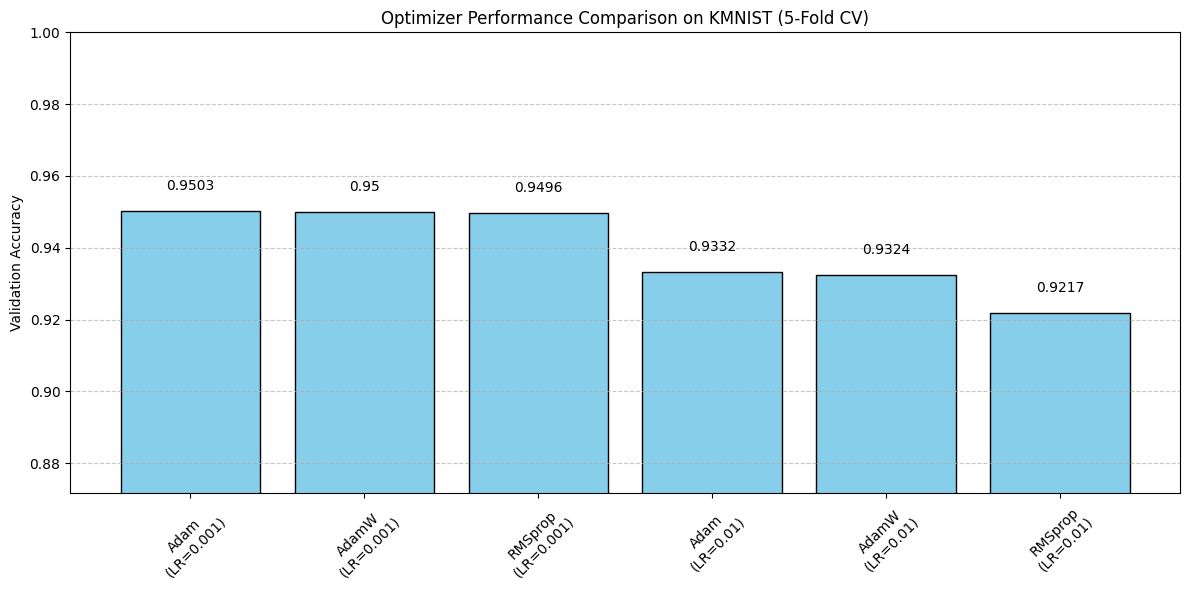

In [13]:
# 5. RESULTS AND VISUALIZATION

# Convert results to a Pandas DataFrame
df_results = pd.DataFrame(results)

# Sort by Accuracy (Descending) to see the best model on top
df_results = df_results.sort_values(by='Avg Val Accuracy', ascending=False)

# Display the table
print("Final Results Table:")
display(df_results)

# Plotting the comparison
plt.figure(figsize=(12, 6))

# Create labels for the X-axis (combining Optimizer and LR)
labels = [f"{row['Optimizer']}\n(LR={row['Learning Rate']})" for _, row in df_results.iterrows()]

# Create bar chart
bars = plt.bar(range(len(df_results)), df_results['Avg Val Accuracy'], color='skyblue', edgecolor='black')

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom')

plt.xticks(range(len(df_results)), labels, rotation=45)
plt.ylabel('Validation Accuracy')
plt.title('Optimizer Performance Comparison on KMNIST (5-Fold CV)')
plt.ylim(min(df_results['Avg Val Accuracy']) - 0.05, 1.0) # Adjust Y-axis to show differences clearly
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()